https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/data

In [1]:
!git clone https://github.com/RomanNenchuk/predictive-maintenance.git
%cd predictive-maintenance

Cloning into 'predictive-maintenance'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 15 (delta 1), reused 15 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 558.28 KiB | 7.16 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/predictive-maintenance


In [2]:
!ls

ai4i_pipe.ipynb  data  README.md  result  transformers.py


In [ ]:
import transformers

In [ ]:
import pandas as pd

* TWF (Tool Wear Failure)
* HDF (Heat Dissipation Failure)
* PWF (Power Failure)
* OSF (Overstrain Failure)
* RNF (Random Failure)

In [ ]:
df = pd.read_csv("data/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

/tmp/ipykernel_16895/694246756.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Machine failure', palette='viridis')


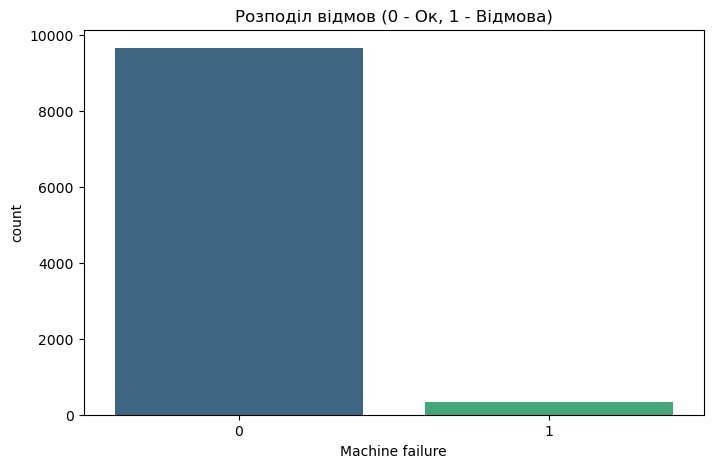

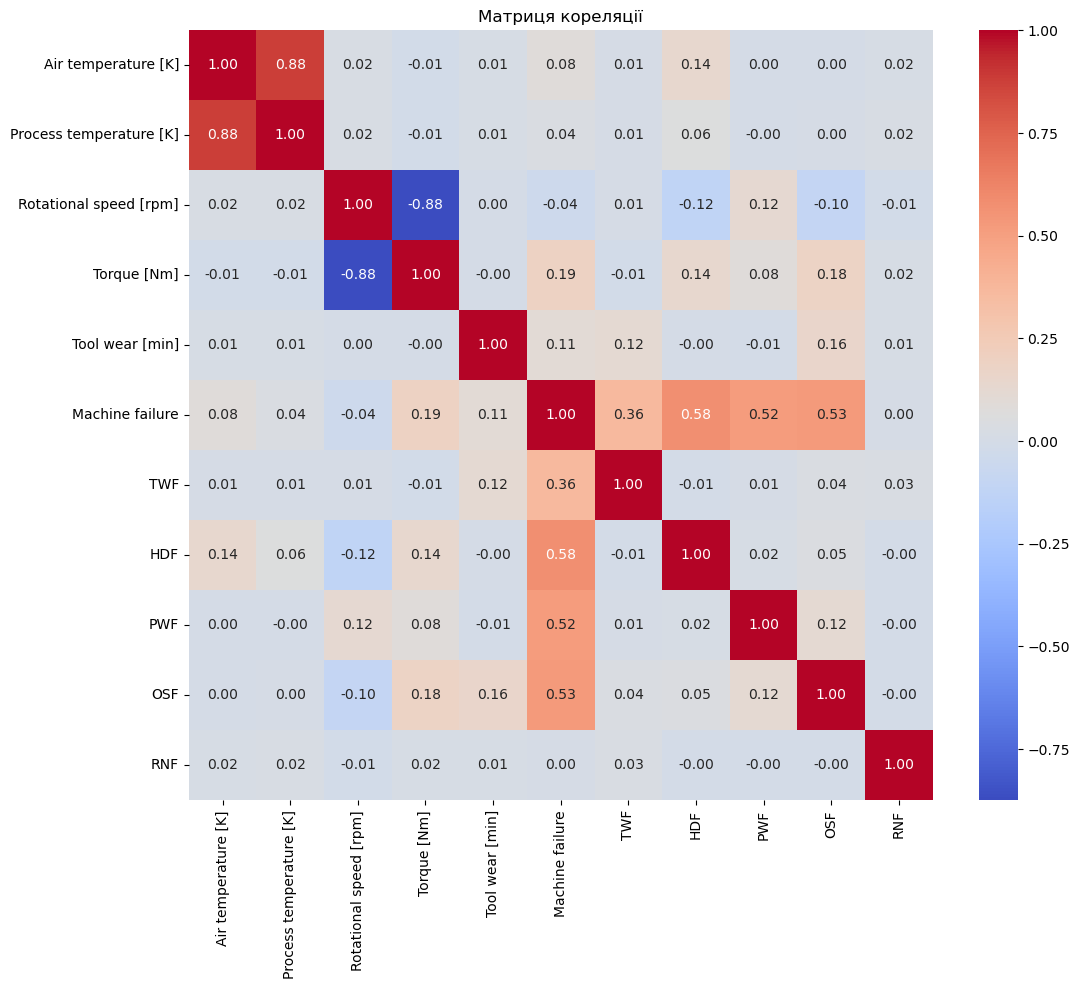

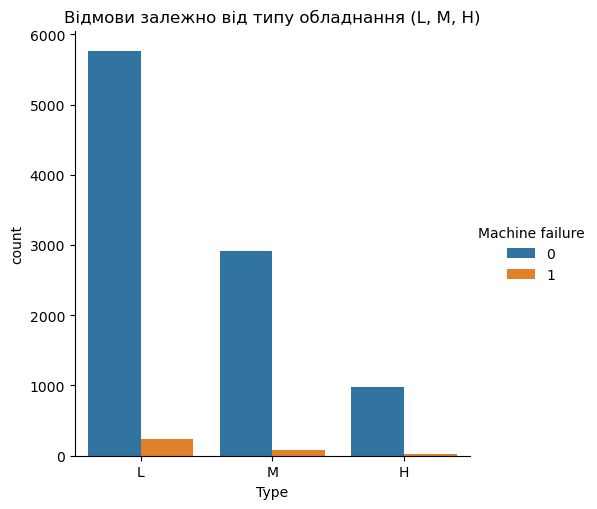

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Візуалізація розподілу цільової змінної
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Machine failure', palette='viridis')
plt.title('Розподіл відмов (0 - Ок, 1 - Відмова)')
plt.show()

# 3. Кореляційна матриця (важливо для вибору ознак)
plt.figure(figsize=(12, 10))
# Видаляємо нечислові колонки для кореляції
corr = df.drop(['UDI', 'Product ID', 'Type'], axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матриця кореляції')
plt.show()

# 4. Аналіз типів обладнання
sns.catplot(data=df, x='Type', hue='Machine failure', kind='count', order=['L', 'M', 'H'])
plt.title('Відмови залежно від типу обладнання (L, M, H)')
plt.show()

In [ ]:
from sklearn.metrics import classification_report


# Вибір ознак (Features) та цільової змінної (Target)
# Видаляємо ID та колонки-причини відмов (витоки даних)
X = df.drop(['UDI', 'Product ID', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
y = df['Machine failure']


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

categorical_features = ['Type']
numeric_features = [col for col in X.columns if col != 'Type']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)


from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])



from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_scores = pipeline.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.90      0.51      0.65        68

    accuracy                           0.98      2000
   macro avg       0.94      0.76      0.82      2000
weighted avg       0.98      0.98      0.98      2000



Модель демонструє поганий recall (повноту), тобто вона пропускає більшість таких поломок. Подивимося на вагу кожної фічі (вагу датчика)

/tmp/ipykernel_16895/2359077009.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


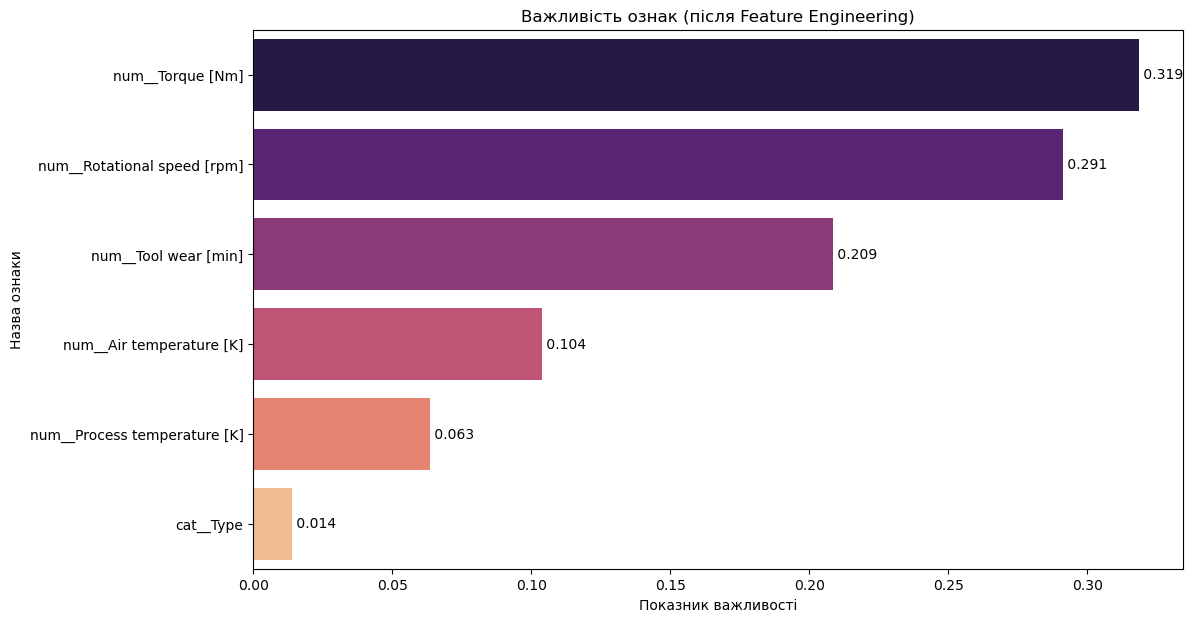

                        Feature  Importance
4              num__Torque [Nm]    0.318651
3   num__Rotational speed [rpm]    0.291418
5          num__Tool wear [min]    0.208614
1      num__Air temperature [K]    0.103992
2  num__Process temperature [K]    0.063462
0                     cat__Type    0.013863


In [ ]:
# Отримуємо важливість ознак
def plot_pipeline_feature_importance(pipeline, model_step='model', preprocessor_step='preprocessing'):
    """
    Витягує та візуалізує важливість ознак з Pipeline.
    """
    # 1. Отримуємо модель та назви ознак
    model = pipeline.named_steps[model_step]

    # Отримуємо назви ознак після трансформації
    feature_names = pipeline.named_steps[preprocessor_step].get_feature_names_out()

    # 2. Створюємо DataFrame
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # 3. Візуалізація
    plt.figure(figsize=(12, 7))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')

    # Додаємо підписи значень на барах для зручності
    for index, value in enumerate(feature_importance_df['Importance']):
        plt.text(value, index, f' {value:.3f}', va='center')

    plt.title('Важливість ознак (після Feature Engineering)')
    plt.xlabel('Показник важливості')
    plt.ylabel('Назва ознаки')
    plt.show()

    return feature_importance_df

# Виклик функції для вашої фінальної моделі
importance_df = plot_pipeline_feature_importance(pipeline)
print(importance_df)

Torque (Крутний момент), Rotational speed (Швидкість обертання) та Tool wear (Знос інструменту) — це наші головні «підозрювані». Разом вони дають понад 80% інформації для моделі.

<br /><br />
Рішення: зміна порогу прийняття рішення

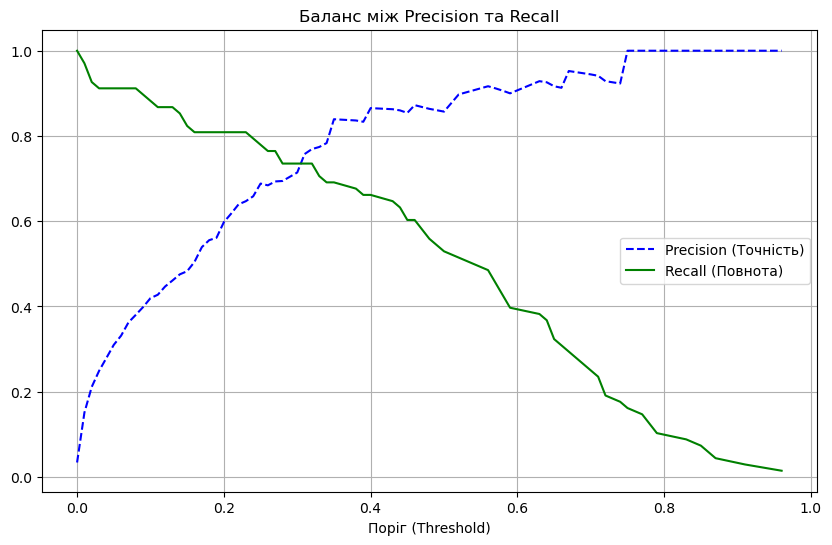


--- Результати з порогом 0.3 ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.71      0.74      0.72        68

    accuracy                           0.98      2000
   macro avg       0.85      0.86      0.86      2000
weighted avg       0.98      0.98      0.98      2000



In [ ]:
from sklearn.metrics import precision_recall_curve, classification_report

# 1. Отримуємо ймовірності, а не просто класи (використовуємо початкову модель без SMOTE або нову)
# Візьмемо модель, навчену на оригінальних даних (можна використати ту, де class_weight='balanced')
y_scores = pipeline.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# 2. Візуалізація залежності Precision та Recall від порогу
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], "b--", label="Precision (Точність)")
plt.plot(thresholds, recall[:-1], "g-", label="Recall (Повнота)")
plt.xlabel("Поріг (Threshold)")
plt.title("Баланс між Precision та Recall")
plt.legend()
plt.grid(True)
plt.show()

# 3. Вибір кастомного порогу (наприклад, 0.3)
custom_threshold = 0.3
y_pred_custom = (y_scores >= custom_threshold).astype(int)

print(f"\n--- Результати з порогом {custom_threshold} ---")
print(classification_report(y_test, y_pred_custom))

In [ ]:

from transformers import FeatureEngineer, CATEGORICAL_FEATURES, NUMERIC_FEATURES
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

# Створюємо препроцесор, використовуючи імпортовані списки
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CATEGORICAL_FEATURES),
        ('num', 'passthrough', NUMERIC_FEATURES)
    ]
)



from sklearn.pipeline import Pipeline
import xgboost as xgb

pipeline_xgb = Pipeline(steps=[
    ('feature_engineering', FeatureEngineer()),
    ('preprocessing', preprocessor),
    ('model', xgb.XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ))
])


X = df.drop(['UDI', 'Product ID', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
y = df['Machine failure']



from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



param_grid = {
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__n_estimators': [100, 200],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}


ratio = float(np.sum(y_train_val == 0)) / np.sum(y_train_val == 1)
pipeline_xgb.set_params(model__scale_pos_weight=ratio)


from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_val, y_train_val)



print(grid_search.best_params_)
print(grid_search.best_score_)


final_model = grid_search.best_estimator_

y_pred = final_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/home/roman/miniconda3/envs/project/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [20:13:20] WARNING: /home/task_177203090464722/croot/xgboost-split_1772031726713/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/roman/miniconda3/envs/project/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [20:13:20] WARNING: /home/task_177203090464722/croot/xgboost-split_1772031726713/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/roman/miniconda3/envs/project/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [20:13:20] WARNING: /home/task_177203090464722/croot/xgboost-split_1772031726713/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/roman/miniconda3/envs/project/lib/python3.12/site-packages/xgboost/training.py:

{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
0.8409400382985289
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.86      0.84      0.85        68

    accuracy                           0.99      2000
   macro avg       0.93      0.92      0.92      2000
weighted avg       0.99      0.99      0.99      2000



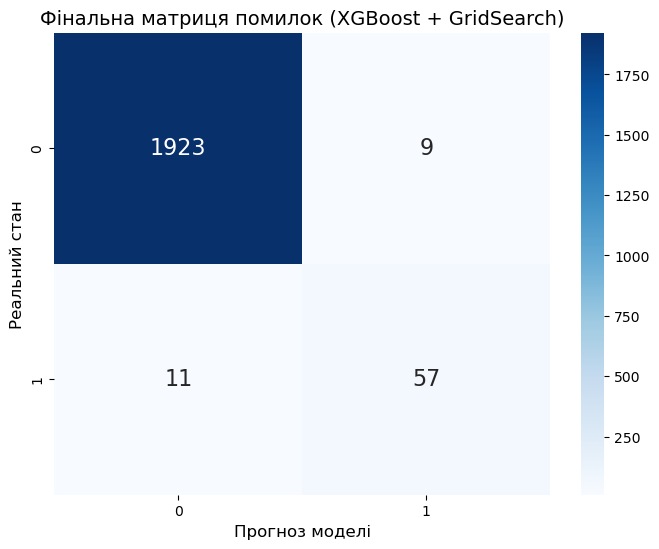

Всього тестів: 2000
Реальних поломок виявлено: 57 з 68
Хибних тривог (марні виїзди майстра): 9


In [ ]:
from sklearn.metrics import confusion_matrix

# Побудова матриці помилок для фінальної моделі
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
plt.xlabel('Прогноз моделі', fontsize=12)
plt.ylabel('Реальний стан', fontsize=12)
plt.title('Фінальна матриця помилок (XGBoost + GridSearch)', fontsize=14)
plt.show()

# Розрахунок специфічної метрики для бізнесу
print(f"Всього тестів: {len(y_test)}")
print(f"Реальних поломок виявлено: {cm[1,1]} з {cm[1,0] + cm[1,1]}")
print(f"Хибних тривог (марні виїзди майстра): {cm[0,1]}")

/tmp/ipykernel_16895/2359077009.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


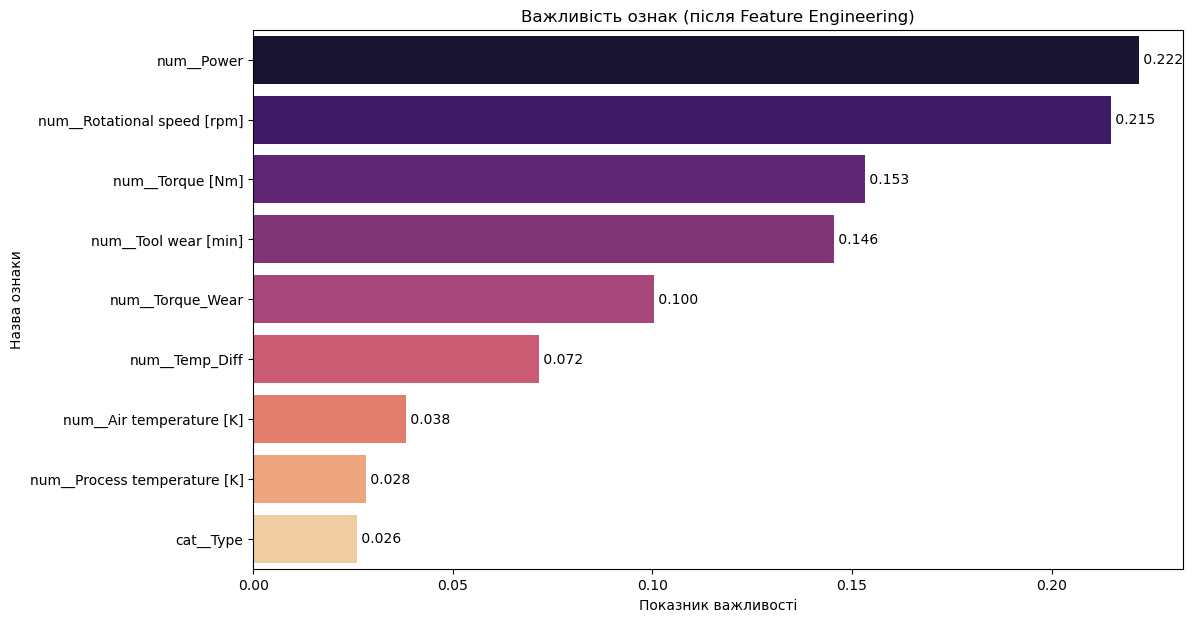

                        Feature  Importance
7                    num__Power    0.221887
3   num__Rotational speed [rpm]    0.214801
4              num__Torque [Nm]    0.153148
5          num__Tool wear [min]    0.145588
8              num__Torque_Wear    0.100427
6                num__Temp_Diff    0.071500
1      num__Air temperature [K]    0.038319
2  num__Process temperature [K]    0.028273
0                     cat__Type    0.026056


In [ ]:
importance_df = plot_pipeline_feature_importance(final_model)
print(importance_df)

Спроба зменшити поріг прийняття рішень для моделі XGBoost

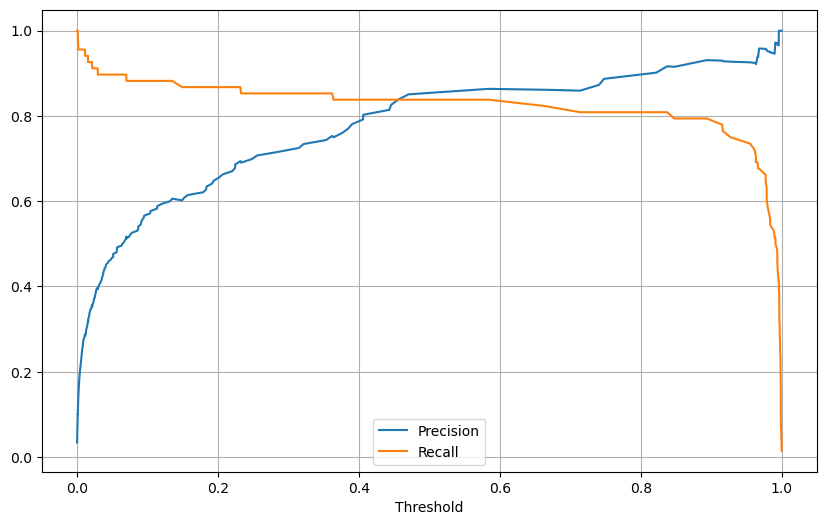

In [ ]:
y_scores = final_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(10,6))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.grid()
plt.show()

In [ ]:
beta = 2

f2_scores = (1 + beta**2) * (precision * recall) / (
    (beta**2 * precision) + recall + 1e-8
)

best_idx = np.argmax(f2_scores)

best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F2:", f2_scores[best_idx])

Best threshold: 0.58395284
Precision: 0.8636363636363636
Recall: 0.8382352941176471
F2: 0.8431952643079725


In [ ]:
import joblib

joblib.dump(final_model, 'result/predictive_maintenance_model_pipe.pkl')

['result/predictive_maintenance_model_pipe.pkl']

### Тестування

In [ ]:
import joblib
import pandas as pd
from transformers import FeatureEngineer

def predict_equipment_status(sensor_data, threshold=0.5):
    model = joblib.load('result/predictive_maintenance_model_pipe.pkl')

    input_df = pd.DataFrame([sensor_data])

    probability = model.predict_proba(input_df)[0][1]
    prediction = probability >= threshold

    return {
        'failure_predicted': bool(prediction),
        'probability': round(float(probability), 4),
        'threshold': threshold,
        'status': "УВАГА: Ризик поломки!" if prediction else "Нормальна робота"
    }

# Дані з "підозрілого" верстата (високий знос + великий момент)
sample_machine_1 = {
    'Type': 'L',
    'Air temperature [K]': 302.1,
    'Process temperature [K]': 310.5,
    'Rotational speed [rpm]': 1350,
    'Torque [Nm]': 65.2,
    'Tool wear [min]': 220
}

sample_machine_2 = {
    'Type': 'L',
    'Air temperature [K]': 299.1,
    'Process temperature [K]': 309.5,
    'Rotational speed [rpm]': 1350,
    'Torque [Nm]': 57.2,
    'Tool wear [min]': 192
}

result = predict_equipment_status(sample_machine_2)

print(f"Статус: {result['status']}")
print(f"Ймовірність відмови: {result['probability'] * 100}%")

Статус: УВАГА: Ризик поломки!
Ймовірність відмови: 71.61%
